# RISE - A Basic Implementation

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage.transform import resize
from skimage.filters import gaussian

np.random.seed(42)  # For reproducibility

## Define a dummy model that detects bright squares in the center of images

In [ ]:
def dummy_model(img) -> float:
    """
    Our black-box model. It returns a high probability (close to 1.0) 
    if the center square is bright, and low if it's hidden.
    """
    # The 'true' object area
    target_area = img[20:44, 20:44]
    # Calculate score based on how much of the target area is illuminated
    score = np.sum(target_area) / (24 * 24)
    # Ensure it stays within a probability range [0, 1]
    return max(0.0, min(1.0, score))

## Create an image to classify

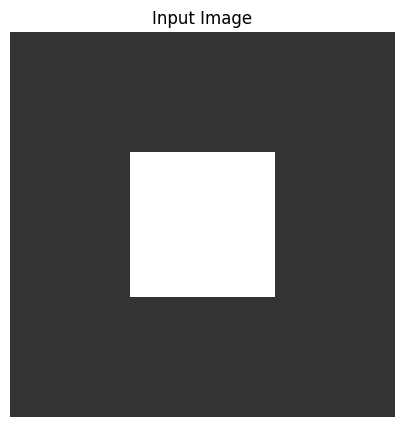

In [44]:
image_size = (64, 64)
image= np.full(image_size, 0.2)
image[20:44, 20:44] = 1.0

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray', vmin=0, vmax=1)
plt.title("Input Image")
plt.axis("off")
plt.show()


## Use the model on the image

In [45]:
score = dummy_model(image)
print(f"Model Confidence: {score}")

Model Confidence: 1.0


## Generate the masks

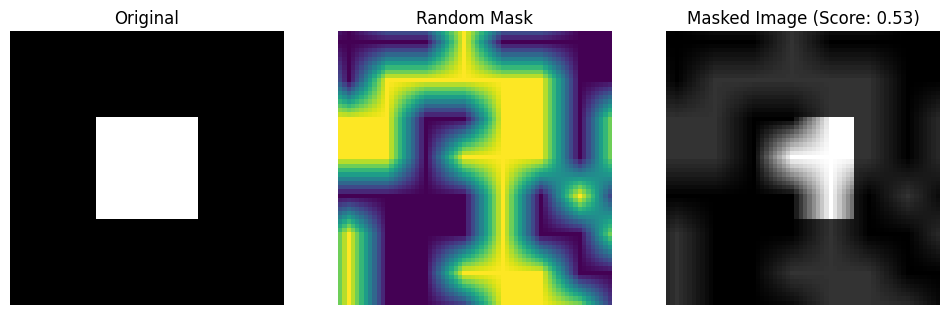

In [46]:
def generate_masks(N, s, p1, input_size):
    """
    N: Number of masks
    s: Size of the smaller grid (e.g., 8x8)
    p1: Probability of a pixel being 1 (usually 0.5)
    input_size: The target size of the image (64, 64)
    """
    cell_size = np.ceil(np.array(input_size) / s)
    up_size = (s + 1) * cell_size
    
    # 1. Sample N binary masks of size s x s
    grid = (np.random.rand(N, s, s) < p1).astype('float32')
    
    masks = np.empty((N, *input_size))
    
    for i in range(N):
        # 2. Upsample using bilinear interpolation
        mask_up = resize(grid[i], up_size, order=1, mode='reflect', anti_aliasing=False)
        
        # 3. Random crop/shift
        x = np.random.randint(0, cell_size[0])
        y = np.random.randint(0, cell_size[1])
        masks[i, :, :] = mask_up[int(x):int(x + input_size[0]), int(y):int(y + input_size[1])]
        
    return masks

# Let's generate 1000 masks
N_masks = 4000
p1 = 0.5
masks = generate_masks(N=N_masks, s=8, p1=p1, input_size=image_size)

# Visualize one of the masks
sample_mask = masks[0]
masked_image = image * sample_mask

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(image, cmap='gray'); ax[0].set_title("Original")
ax[1].imshow(sample_mask, cmap='viridis'); ax[1].set_title("Random Mask")
ax[2].imshow(masked_image, cmap='gray'); ax[2].set_title(f"Masked Image (Score: {dummy_model(masked_image):.2f})")
for a in ax: a.axis('off')
plt.show()

## Probing the model with the masks

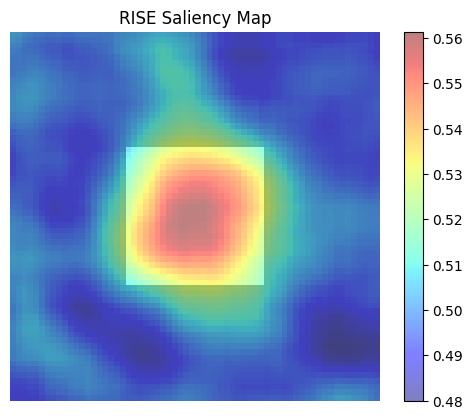

In [47]:
# 1. Probe the model with all masks and save the scores
preds = []
for mask in masks:
    masked_img = image * mask
    preds.append(dummy_model(masked_img))

preds = np.array(preds)

# 2. Generate Saliency Map (Weighted sum of masks)
# Use tensordot to efficiently multiply each mask by its corresponding prediction score and sum them up
saliency = np.tensordot(preds, masks, axes=1)

# 3. Normalize by the expected value of the mask (p1) and number of masks (N)
saliency = saliency / (N_masks * p1)

# Visualize the result
plt.imshow(image, cmap='gray', alpha=0.5)
plt.imshow(saliency, cmap='jet', alpha=0.5) # Overlay heatmap
plt.title("RISE Saliency Map")
plt.axis('off')
plt.colorbar()
plt.show()

## Evaluate the Explanation (Saliency Map) with Deletion and Insertion Metrics

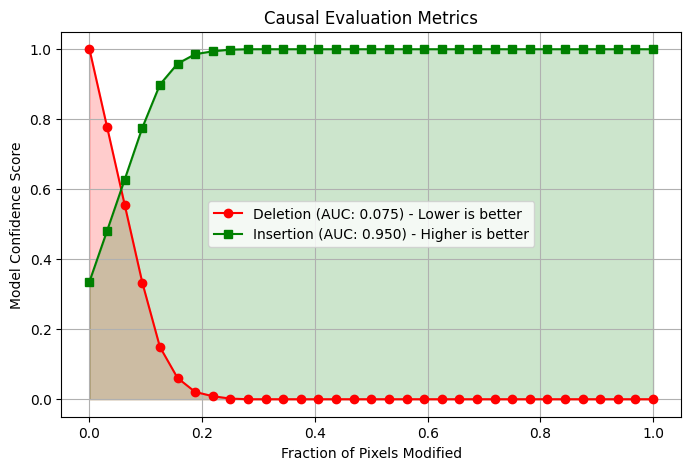

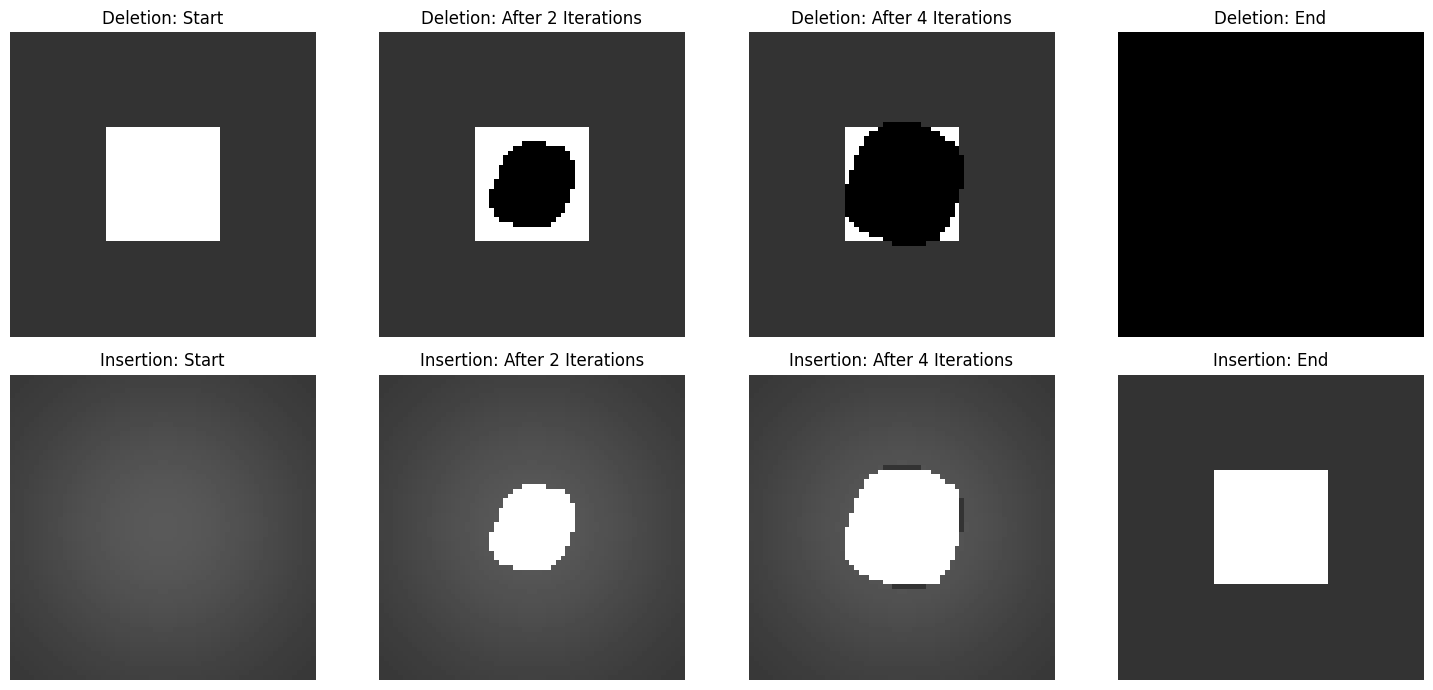

In [48]:
# Flatten and sort pixels by saliency (highest to lowest)
sal_flat = saliency.flatten()
sort_indices = np.argsort(sal_flat)[::-1] 

# Calculate step size to remove/insert pixels in chunks (e.g., 32 steps)
step_size = len(sort_indices) // 32

# --- DELETION METRIC ---
img_del = image.copy()
gray_val = 0.0     # Use black for deleted pixels

# Record the initial score before any pixels are deleted
del_scores = [dummy_model(img_del)] 

# List to visualize the deletion process
del_frames = [img_del.copy()]

step_count = 0
for i in range(0, len(sort_indices), step_size):
    # Get the indices of the next batch of highly salient pixels
    idx = sort_indices[i:i+step_size]
    # Mask them out (set to the constant gray value)
    np.put(img_del, idx, gray_val)
    # Record the model's new score
    del_scores.append(dummy_model(img_del))

    step_count += 1
    if step_count == 2 or step_count == 4:
        del_frames.append(img_del.copy())

del_frames.append(img_del.copy())

# --- INSERTION METRIC ---
# Start with a heavily blurred version of the image
img_ins = gaussian(image, sigma=21) 

# Record the initial score of the fully blurred image before inserting anything
ins_scores = [dummy_model(img_ins)] 

# List to visualize the insertion process
ins_frames = [img_ins.copy()]

step_count = 0
for i in range(0, len(sort_indices), step_size):
    idx = sort_indices[i:i+step_size]
    # Get the original, sharp pixel values for these salient locations
    orig_vals = np.take(image, idx)
    # Insert them into the blurred canvas (effectively unblurring them)
    np.put(img_ins, idx, orig_vals)
    # Record the model's new score
    ins_scores.append(dummy_model(img_ins))

    step_count += 1
    if step_count == 2 or step_count == 4:
        ins_frames.append(img_ins.copy())

ins_frames.append(img_ins.copy())

# --- PLOTTING GRAPH ---
# The x_axis will automatically adjust to the length of the scores
x_axis = np.linspace(0, 1, len(del_scores)) 

# Calculate the Area Under the Curve (AUC) using the trapezoidal rule
del_auc = np.trapezoid(del_scores, x_axis)
ins_auc = np.trapezoid(ins_scores, x_axis)

plt.figure(figsize=(8, 5))

# Plot the lines
plt.plot(x_axis, del_scores, label=f'Deletion (AUC: {del_auc:.3f}) - Lower is better', color='red', marker='o')
plt.plot(x_axis, ins_scores, label=f'Insertion (AUC: {ins_auc:.3f}) - Higher is better', color='green', marker='s')

# Visually fill the Area Under the Curve (AUC)
# We use alpha=0.2 to make it transparent so overlapping regions remain visible
plt.fill_between(x_axis, 0, del_scores, color='red', alpha=0.2)
plt.fill_between(x_axis, 0, ins_scores, color='green', alpha=0.2)

plt.title("Causal Evaluation Metrics")
plt.xlabel("Fraction of Pixels Modified")
plt.ylabel("Model Confidence Score")
plt.legend()
plt.grid(True)
plt.show()

# --- PLOTTING IMAGE PROGRESSION ---
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
titles = ["Start", "After 2 Iterations", "After 4 Iterations", "End"]

for col in range(4):
    # Plot Deletion frames (Top Row)
    axes[0, col].imshow(del_frames[col], cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(f"Deletion: {titles[col]}")
    axes[0, col].axis('off')
    
    # Plot Insertion frames (Bottom Row)
    axes[1, col].imshow(ins_frames[col], cmap='gray', vmin=0, vmax=1)
    axes[1, col].set_title(f"Insertion: {titles[col]}")
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()